<a href="https://colab.research.google.com/github/pushpakgaidhane294/NNDL_lab/blob/main/Practical7_NNDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow version: 2.20.0

--- STEP 1: Upload your image ---


Saving 2022-02-04-test_image.jpg to 2022-02-04-test_image (5).jpg
Successfully uploaded: 2022-02-04-test_image (5).jpg
Image size: 800 x 500


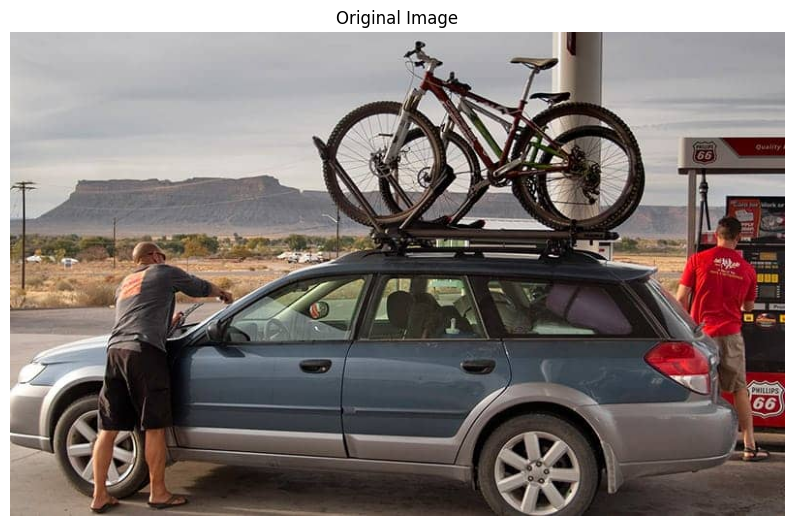


--- STEP 2: Loading SSD MobileNet model ---
SSD MobileNet model loaded successfully!

--- STEP 3: Performing object detection ---

--- STEP 4: Detected Objects ---
bicycle : 81.46%
car : 77.08%
person : 67.96%
person : 67.23%
car : 53.34%

--- Detection Accuracy / Confidence ---
Average Detection Confidence : 69.41%
Highest Detection Confidence : 81.46%
Lowest Detection Confidence : 53.34%
Total Objects Detected : 5

--- STEP 5: Final Detection Result ---


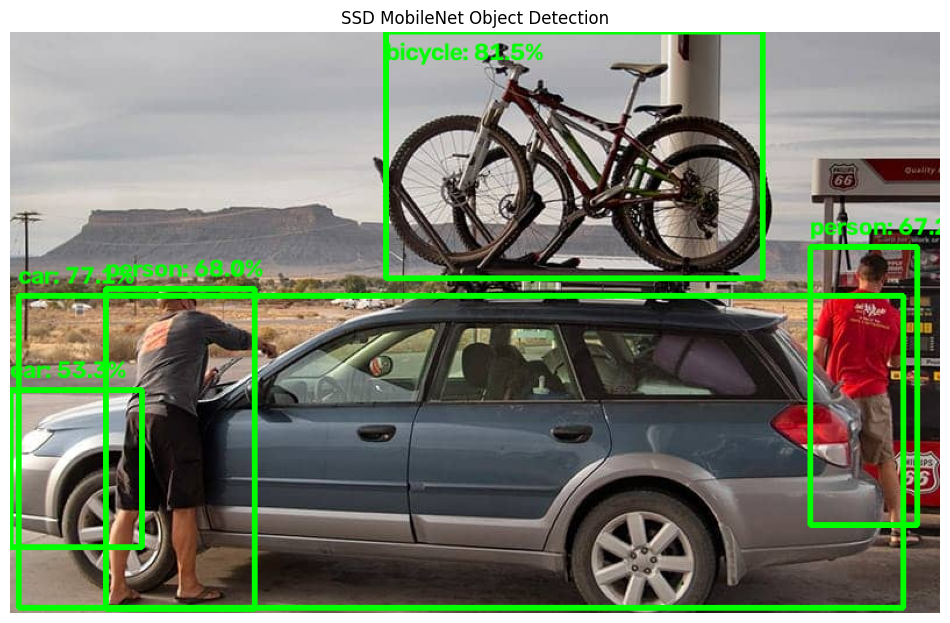


Object detection completed successfully!


In [13]:
# OBJECT DETECTION USING SSD MOBILENET

!pip -q install tensorflow-hub

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import cv2

print("TensorFlow version:", tf.__version__)

# STEP 1: UPLOAD IMAGE
print("\n--- STEP 1: Upload your image ---")
uploaded = files.upload()
if not uploaded:
    raise Exception("No image uploaded.")
image_path = list(uploaded.keys())[0]
print("Successfully uploaded:", image_path)

# STEP 2: LOAD IMAGE
image = Image.open(image_path).convert("RGB")
image_np = np.array(image)
height, width, _ = image_np.shape
print("Image size:", width, "x", height)
plt.figure(figsize=(10, 7))
plt.imshow(image_np)
plt.axis("off")
plt.title("Original Image")
plt.show()

# STEP 3: LOAD PRE-TRAINED SSD MOBILENET
print("\n--- STEP 2: Loading SSD MobileNet model ---")
MODEL_URL = "https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2"
detector = hub.load(MODEL_URL)
print("SSD MobileNet model loaded successfully!")

# STEP 4: PRE-PROCESS IMAGE
input_tensor = tf.convert_to_tensor(
    image_np,
    dtype=tf.uint8
)
input_tensor = input_tensor[tf.newaxis, ...]

# STEP 5: OBJECT DETECTION
print("\n--- STEP 3: Performing object detection ---")
detections = detector(input_tensor)
boxes = detections["detection_boxes"][0].numpy()
classes = detections["detection_classes"][0].numpy().astype(np.int32)
scores = detections["detection_scores"][0].numpy()

# STEP 6: COCO CLASS LABELS
COCO_CLASSES = {
    1:"person", 2:"bicycle", 3:"car", 4:"motorcycle",
    5:"airplane", 6:"bus", 7:"train", 8:"truck",
    9:"boat", 16:"bird", 17:"cat", 18:"dog",
    19:"horse", 20:"sheep", 21:"cow", 22:"elephant",
    23:"bear", 24:"zebra", 25:"giraffe",
    27:"backpack", 28:"umbrella", 31:"handbag",
    32:"tie", 33:"suitcase", 34:"frisbee",
    37:"sports ball", 39:"baseball bat",
    40:"baseball glove", 41:"skateboard",
    42:"surfboard", 43:"tennis racket",
    44:"bottle", 46:"wine glass", 47:"cup",
    48:"fork", 49:"knife", 50:"spoon", 51:"bowl",
    52:"banana", 53:"apple", 54:"sandwich",
    55:"orange", 56:"broccoli", 57:"carrot",
    58:"hot dog", 59:"pizza", 60:"donut",
    61:"cake", 62:"chair", 63:"couch",
    64:"potted plant", 65:"bed", 67:"dining table",
    70:"toilet", 72:"tv", 73:"laptop", 74:"mouse",
    75:"remote", 76:"keyboard", 77:"cell phone",
    78:"microwave", 79:"oven", 80:"toaster",
    81:"sink", 82:"refrigerator", 84:"book",
    85:"clock", 86:"vase", 87:"scissors",
    88:"teddy bear", 89:"hair drier", 90:"toothbrush"
}

# STEP 7: FILTER DETECTIONS

CONFIDENCE_THRESHOLD = 0.50
NMS_THRESHOLD = 0.35
boxes_for_nms = []
confidences = []
class_ids = []
for i in range(len(scores)):
    confidence = float(scores[i])
    class_id = int(classes[i])
    if confidence >= CONFIDENCE_THRESHOLD and class_id in COCO_CLASSES:
        ymin, xmin, ymax, xmax = boxes[i]
        x = int(xmin * width)
        y = int(ymin * height)
        w = int((xmax - xmin) * width)
        h = int((ymax - ymin) * height)

        if w > 0 and h > 0:

            boxes_for_nms.append([x, y, w, h])
            confidences.append(confidence)
            class_ids.append(class_id)

# STEP 8: APPLY NON-MAXIMUM SUPPRESSION
indices = cv2.dnn.NMSBoxes(
    boxes_for_nms,
    confidences,
    CONFIDENCE_THRESHOLD,
    NMS_THRESHOLD
)
result = image_np.copy()
detected_objects = []
if len(indices) > 0:
    indices = np.array(indices).flatten()
    for i in indices:
        x, y, w, h = boxes_for_nms[i]
        class_id = class_ids[i]
        confidence = confidences[i]
        object_name = COCO_CLASSES[class_id]
        x = max(0, x)
        y = max(0, y)
        w = min(w, width - x)
        h = min(h, height - y)
        detected_objects.append(
            (object_name, confidence)
        )

        cv2.rectangle(result,(x, y),(x + w, y + h),(0, 255, 0),3)
        label = f"{object_name}: {confidence * 100:.1f}%"
        cv2.putText(result, label,(x, max(y - 10, 25)),cv2.FONT_HERSHEY_SIMPLEX,0.7,(0, 255, 0),2)

# STEP 9: DISPLAY DETECTED OBJECTS
print("\n--- STEP 4: Detected Objects ---")
if len(detected_objects) == 0:

    print("No objects detected.")
    average_confidence = 0

else:

    for object_name, confidence in detected_objects:

        print(
            f"{object_name} : "
            f"{confidence * 100:.2f}%"
        )
    # Calculate average detection confidence
    confidence_values = [
        confidence for object_name, confidence in detected_objects
    ]
    average_confidence = np.mean(confidence_values)
    highest_confidence = np.max(confidence_values)
    lowest_confidence = np.min(confidence_values)

    print("\n--- Detection Accuracy / Confidence ---")
    print(
        f"Average Detection Confidence : "

        f"{average_confidence * 100:.2f}%"
    )
    print(
        f"Highest Detection Confidence : "
        f"{highest_confidence * 100:.2f}%"
    )
    print(
        f"Lowest Detection Confidence : "
        f"{lowest_confidence * 100:.2f}%"
    )
    print(
        f"Total Objects Detected : "
        f"{len(detected_objects)}"
    )
# STEP 10: DISPLAY FINAL IMAGE
print("\n--- STEP 5: Final Detection Result ---")
plt.figure(figsize=(12, 9))
plt.imshow(result)
plt.axis("off")
plt.title("SSD MobileNet Object Detection")
plt.show()
print("\nObject detection completed successfully!")